# S1 Backtest — OOS tearsheet

Set **`N_STAR`**, **`TIMING_STAR`**, **`WEIGHT_STAR`**, **`INV_VOL_WINDOW_STAR`** (if `inv_vol`),
**`STOP_STAR`**, **`VT_STAR`**, and **`IC_STAR`** by hand from notebooks 01–07. No further search.

Run the full sample and report **IS** and **OOS** (post-IS) statistics separately —
QuantConnect-style review with emphasis on OOS, plus underperformance diagnostics
(losing months, regimes, IC stability/decay, turnover drag, weight concentration).

Signal: 05 slim-ffill Ridge. Costs: Alpaca-representative open/close one-way bps.


## 0. Imports & Config


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import (
    WEIGHT_EQUAL,
    WEIGHT_INV_VOL,
    WEIGHT_RANK,
    WEIGHT_SCORE,
)
from backtest.s1_equities.report import (
    compare_segments,
    concentration_vs_returns,
    ic_horizon_decay,
    ic_stability_summary,
    losing_months_summary,
    plot_concentration,
    plot_cost_drag_vs_turnover,
    plot_drawdown,
    plot_equity_overlay,
    plot_feature_attrition,
    plot_losing_months,
    plot_rolling_ic,
    plot_rolling_sharpe,
    regime_performance,
    split_period_returns,
    spy_weekly_open_returns,
    turnover_drag_summary,
    write_tearsheet_pdf,
)
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.stops import parse_stop_star
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from data.processing.feature_implementation.realized_vol import DEFAULT_OPEN_VOL_WINDOW
from models.s1_equities.training_common import (
    LABEL_COL,
    LABEL_COL_MON_FRI,
    date_ic_series,
    feature_attrition_summary,
)
from risk.s1_equities.signal_conviction import parse_ic_scale_star
from risk.s1_equities.vol_targeting import parse_vol_target_star

PATHS = default_backtest_paths(ROOT)
ART = PATHS["artifacts"]
os.makedirs(ART, exist_ok=True)

# --- Set from notebooks 01 / 02 / 03 / 05 / 06 / 07 (suggested values printed there) ---
N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN  # or TIMING_MON_OPEN_FRI_CLOSE
WEIGHT_STAR = WEIGHT_INV_VOL  # or WEIGHT_SCORE / WEIGHT_RANK / WEIGHT_INV_VOL
# From notebook 03 §5 when WEIGHT_STAR is inv_vol (ignored otherwise)
INV_VOL_WINDOW_STAR = 42
STOP_STAR = "pct_20"  # "none" | "atr_14_3" from 05 | "pct_5" from 06
VT_STAR = 'vt_bayes_0.9_10_q0.75_db0.05'
IC_STAR = 'ic_k15_0.94_f0.25_c1.25'

PRED_PATH = prediction_path_for_timing(PATHS, TIMING_STAR)

FEATURE_COLS_ATTRITION = [
    "raw_momentum_252_5",
    "smart_residual_mom_189_42",
    "rel_downside_beta_252",
    "rel_upside_beta_63",
    "smart_beta_hml_252",
    "downside_beta_42",
    "upside_beta_42",
    "size_mom_126",
    "val_roc_pb_252",
    "val_roc_pe_252",
    "log_mcap",
    "val_mom_dist_252_21",
    "gross_profitability",
    "filing_clock_expected_until",
    "short_flow_ratio",
    "market_corr",
    "beta_mkt_interact",
    "abnormal_volume",
    "gdelt_tone_x_attention_21",
    "gdelt_attention_5",
]

print(f"N_STAR={N_STAR} (notebook parameter)")
print(f"TIMING_STAR={TIMING_STAR} (notebook parameter)")
print(f"WEIGHT_STAR={WEIGHT_STAR} (notebook parameter)")
print(f"INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR} (used when WEIGHT_STAR=inv_vol)")
print(f"STOP_STAR={STOP_STAR} (notebook parameter)")
print(f"VT_STAR={VT_STAR} (notebook parameter)")
print(f"IC_STAR={IC_STAR} (notebook parameter)")
print(f"predictions={PRED_PATH}")
STOP_CFG = parse_stop_star(STOP_STAR)
VT_CFG = parse_vol_target_star(VT_STAR)
IC_CFG = parse_ic_scale_star(IC_STAR)
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15 (notebook parameter)
TIMING_STAR=mon_open_mon_open (notebook parameter)
WEIGHT_STAR=inv_vol (notebook parameter)
INV_VOL_WINDOW_STAR=42 (used when WEIGHT_STAR=inv_vol)
STOP_STAR=pct_20 (notebook parameter)
VT_STAR=vt_bayes_0.9_10_q0.75_db0.05 (notebook parameter)
IC_STAR=ic_k15_0.94_f0.25_c1.25 (notebook parameter)
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Load & run full-sample backtest


In [2]:
preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)
opens, highs, lows, closes = load_ohlc_panels(PATHS["features"], tickers=list(scores.columns))

label_col = LABEL_COL_MON_FRI if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE else LABEL_COL
ic_inputs = None
if IC_CFG.enabled:
    if label_col not in preds.columns:
        raise ValueError(f"predictions missing {label_col} for IC overlay")
    ics = date_ic_series(preds, "score", label_col=label_col)
    n_names = preds.groupby("date")["ticker"].nunique()
    n_names.index = pd.to_datetime(n_names.index)
    ic_inputs = pd.DataFrame({"ic": ics, "n_names": n_names}).sort_index()

result = run_backtest(
    scores,
    opens,
    closes,
    n=N_STAR,
    timing_mode=TIMING_STAR,
    weight_mode=WEIGHT_STAR,
    inv_vol_window=INV_VOL_WINDOW_STAR,
    costs=DEFAULT_COSTS,
    date_mask=None,  # full sample; split in reporting
    highs=highs,
    lows=lows,
    stop=STOP_CFG,
    vol_target=VT_CFG,
    ic_scale=IC_CFG,
    ic_inputs=ic_inputs,
)
print(
    f"periods={len(result.period_returns)}  "
    f"span={result.period_returns.index.min().date()} -> {result.period_returns.index.max().date()}"
)

S1_RETURNS_PATH = os.path.join(ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet")
os.makedirs(os.path.dirname(S1_RETURNS_PATH), exist_ok=True)
s1_ret = result.period_returns.rename("ret").to_frame()
s1_ret.index = pd.to_datetime(s1_ret.index)
s1_ret.index.name = "date"
s1_ret.to_parquet(S1_RETURNS_PATH)
print(f"wrote S1 weekly period returns -> {S1_RETURNS_PATH}  n={len(s1_ret)}")


periods=591  span=2015-03-23 -> 2026-07-13
wrote S1 weekly period returns -> c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_period_returns.parquet  n=591


## 2. IS vs OOS metrics


In [3]:
is_dates = is_mask.index[is_mask]
metrics = compare_segments(result, is_dates)
display(metrics)

# Explicit OOS-only summary line
oos = metrics.loc["OOS"]
print(
    f"OOS: Sharpe={oos['sharpe']:.3f}  AvgAnn={oos['avg_ann_return']:.3%}  "
    f"CAGR={oos['cagr']:.3%}  MaxDD={oos['max_drawdown']:.3%}  "
    f"periods={int(oos['n_periods'])}"
)
is_row = metrics.loc["IS"]
print(
    f"IS:  Sharpe={is_row['sharpe']:.3f}  AvgAnn={is_row['avg_ann_return']:.3%}  "
    f"CAGR={is_row['cagr']:.3%}  MaxDD={is_row['max_drawdown']:.3%}  "
    f"periods={int(is_row['n_periods'])}"
)


,n_periods,total_return,avg_ann_return,cagr,vol,sharpe,max_drawdown,win_rate,mean_return,sharpe_vbt,sortino_vbt,calmar_vbt,max_dd_vbt
segment,,,,,,,,,,,,,
IS,411,0.866977,0.081857,0.082193,0.075063,1.090517,-0.097923,0.583942,0.001574,1.090517,1.703965,0.839362,-0.097923
OOS,180,0.098833,0.028839,0.027601,0.056842,0.507351,-0.075703,0.555556,0.000555,0.507351,0.767821,0.364602,-0.075703
FULL,591,1.051495,0.065710,0.065266,0.070051,0.938021,-0.097923,0.575296,0.001264,0.938021,1.456779,0.666500,-0.097923


OOS: Sharpe=0.507  AvgAnn=2.884%  CAGR=2.760%  MaxDD=-7.570%  periods=180
IS:  Sharpe=1.091  AvgAnn=8.186%  CAGR=8.219%  MaxDD=-9.792%  periods=411


## 3. Performance overview

Headline equity / risk visuals only. Deep-dive diagnostics are in section 4.

### 3.1 Equity (net vs gross)

**Gross** (`result.equity_gross`) compounds hold-period price P&L only.
**Net** (`result.equity`) is the same path after Alpaca-representative trading costs
(half-spread, open/close slippage, regulatory bps) charged on turnover.

This is not net/gross *exposure* — both curves use the same (possibly levered) weights;
the gap is cumulative cost drag. Headline Sharpe / CAGR / MaxDD use **net**.


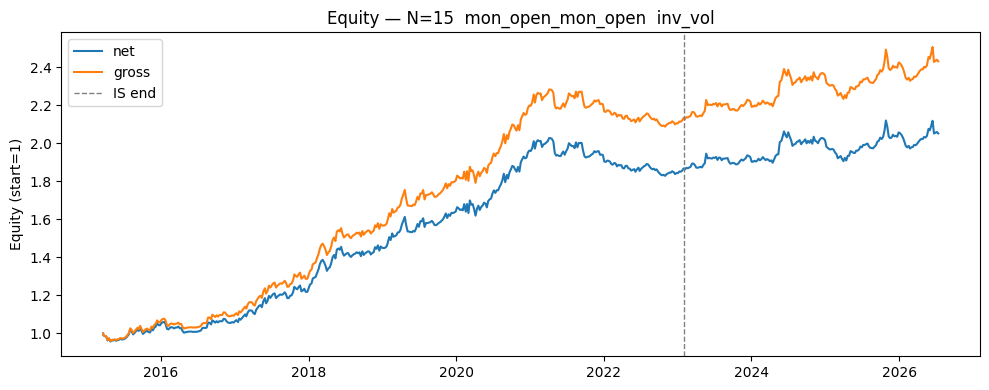

In [4]:
is_end = is_dates.max()
_, oos_rets = split_period_returns(result.period_returns, is_dates)

fig = plot_equity_overlay(
    {"net": result.equity, "gross": result.equity_gross},
    title=f"Equity — N={N_STAR}  {TIMING_STAR}  {WEIGHT_STAR}",
    is_end=is_end,
)
plt.show()


### 3.2 Drawdown

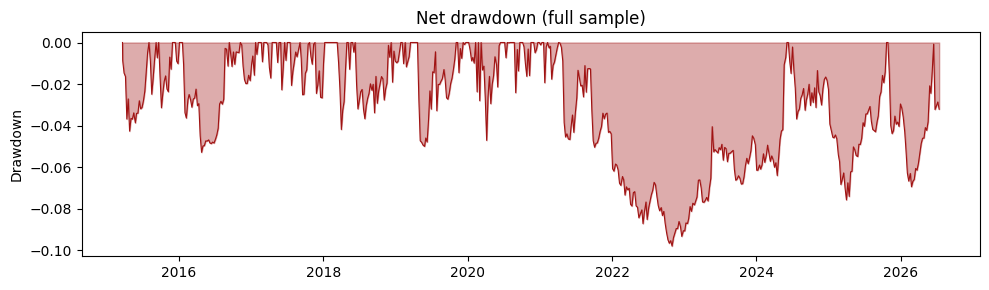

In [5]:
fig = plot_drawdown(result.equity, title="Net drawdown (full sample)")
plt.show()


### 3.3 OOS rolling Sharpe

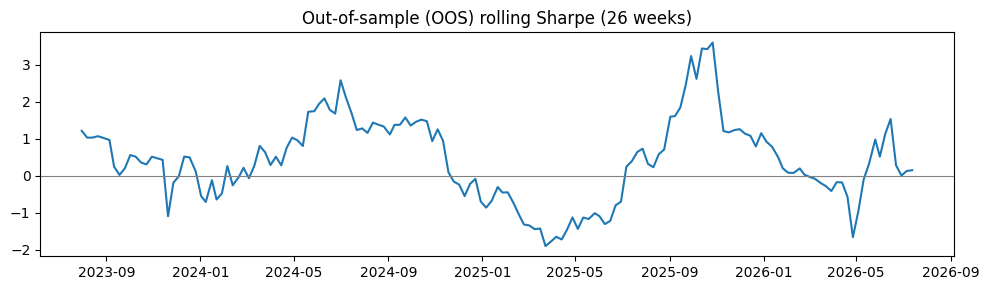

In [6]:
fig = plot_rolling_sharpe(
    oos_rets,
    window=26,
    title="Out-of-sample (OOS) rolling Sharpe (26 weeks)",
)
plt.show()


## 4. Underperformance diagnostics

Descriptive OOS diagnostics only — do not retune parameters on this slice.


### 4.1 Losing months

Compound weekly OOS returns to calendar months; list worst months and yearly hit-rate.


,monthly_return
2025-11-01,-0.042346
2025-01-01,-0.023790
2026-01-01,-0.022774
2025-03-01,-0.019531
2026-02-01,-0.018684
2024-07-01,-0.018572
2023-09-01,-0.013840
2025-08-01,-0.012594
2025-02-01,-0.011999
2024-01-01,-0.010258


,pct_months_up
year,
2023,0.636364
2024,0.583333
2025,0.583333
2026,0.428571


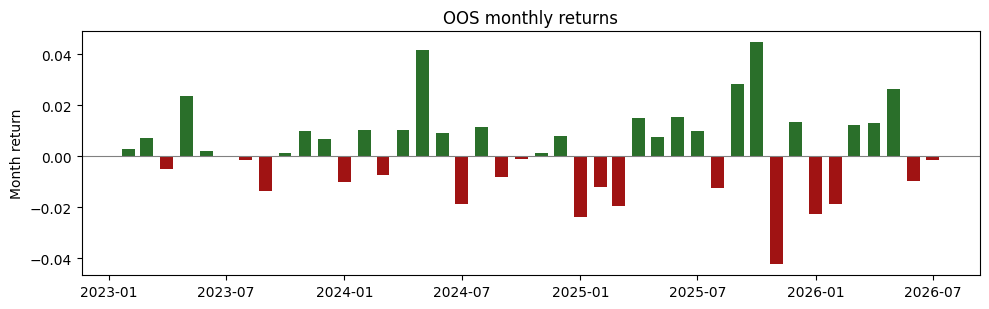

In [7]:
lm = losing_months_summary(oos_rets)
display(lm["worst"])
display(lm["pct_months_up_by_year"].to_frame())
fig = plot_losing_months(lm["monthly"], title="OOS monthly returns")
plt.show()


### 4.2 Regimes

SPY open-to-open weekly return (Up/Down) and trailing-26w SPY vol terciles.
Vol cutpoints are fit on **IS** trailing vol only, then applied to OOS.


In [8]:
spy_w = spy_weekly_open_returns(result.period_returns.index)
regimes = regime_performance(oos_rets, spy_w, is_dates)
print("Vol cutpoints (IS):")
display(regimes["vol_cutpoints"].to_frame("value"))
print("By market direction:")
display(regimes["market"])
print("By vol tercile:")
display(regimes["vol"])


Vol cutpoints (IS):


,value
q33,0.015382
q66,0.026734


By market direction:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
Down,71,-0.003310,-0.211261,-3.217018,0.323944
Up,109,0.003072,0.393150,3.098509,0.706422


By vol tercile:


,n,mean_return,total_return,sharpe,win_rate
regime,,,,,
Mid,109,0.000277,0.027874,0.281943,0.559633
Low,44,0.000285,0.010193,0.194248,0.522727
High,27,0.002114,0.058248,2.738935,0.592593


### 4.3 IC stability and decay

Per-date Spearman IC of score vs the timing label; rolling mean IC; horizon decay.


,mean_ic,std_ic,icir,n
IS,0.046508,0.228313,0.203704,411.0
OOS,0.030692,0.254365,0.120662,181.0


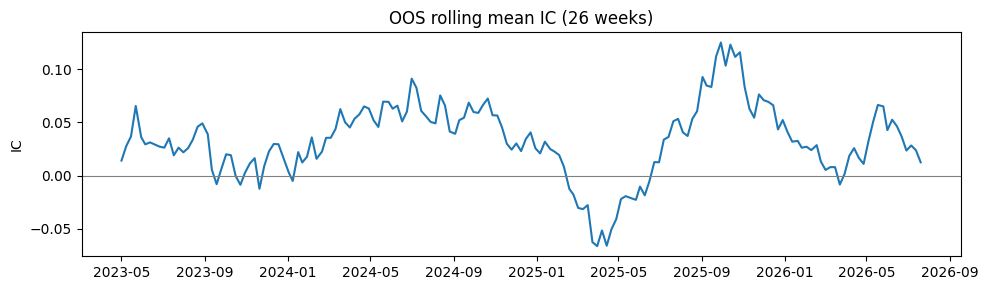

,mean_ic,std_ic,icir,n
horizon,,,,
fwd_ret_1,0.040218,0.240063,0.167529,592
fwd_ret_5,0.041673,0.236477,0.176222,592
fwd_ret_21,0.082046,0.231185,0.354896,588


In [9]:
LABEL_STAR = (
    LABEL_COL_MON_FRI
    if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE
    else LABEL_COL
)
ic = ic_stability_summary(preds, is_dates, label_col=LABEL_STAR)
display(ic["segment"])
fig = plot_rolling_ic(ic["ics_oos"], title="OOS rolling mean IC (26 weeks)")
plt.show()
decay = ic_horizon_decay(preds, PATHS["features"])
display(decay)


### 4.4 Turnover drag

Gross vs net edge and cost drag versus one-way turnover.


,value
mean_turnover,0.131221
median_turnover,0.126615
mean_cost_drag,0.000203
mean_cost_over_abs_gross,0.036258
sharpe_net,0.507351
sharpe_gross,0.694079
corr_turnover_drag,0.999965


,turnover,cost_drag,ret_net,ret_gross
turnover,1.000000,0.999965,-0.083363,-0.068249
cost_drag,0.999965,1.000000,-0.083238,-0.068123
ret_net,-0.083363,-0.083238,1.000000,0.999885
ret_gross,-0.068249,-0.068123,0.999885,1.000000


Mean turnover=0.1312  Median=0.1266


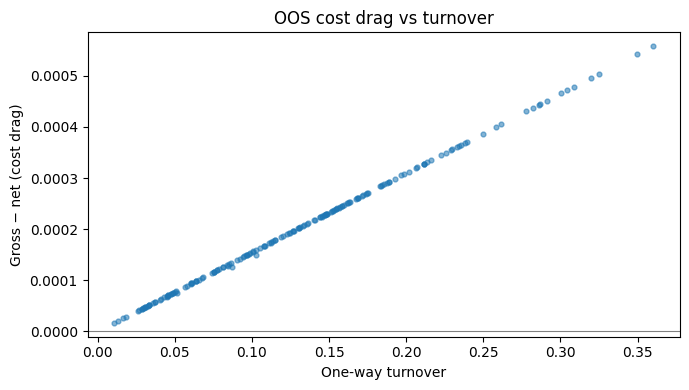

In [10]:
drag = turnover_drag_summary(result, is_dates)
display(drag["summary"].to_frame("value"))
display(drag["corr"])
print(
    f"Mean turnover={drag['summary']['mean_turnover']:.4f}  "
    f"Median={drag['summary']['median_turnover']:.4f}"
)
fig = plot_cost_drag_vs_turnover(drag["frame"])
plt.show()


### 4.5 Weight concentration

Per-date max |w| / HHI on OOS entry weights; correlation with period returns.


,value
n_dates,180.000000
max_abs_w_mean,0.059145
max_abs_w_p50,0.058237
max_abs_w_p95,0.073870
max_abs_w_max,0.086045
min_abs_w_mean,0.015106
hhi_mean,0.036546
long_max_share_mean,0.115321
long_max_share_max,0.172090
short_max_share_mean,0.101106


,hhi,max_abs_w,ret
hhi,1.000000,0.738522,0.020296
max_abs_w,0.738522,1.000000,0.057023
ret,0.020296,0.057023,1.000000


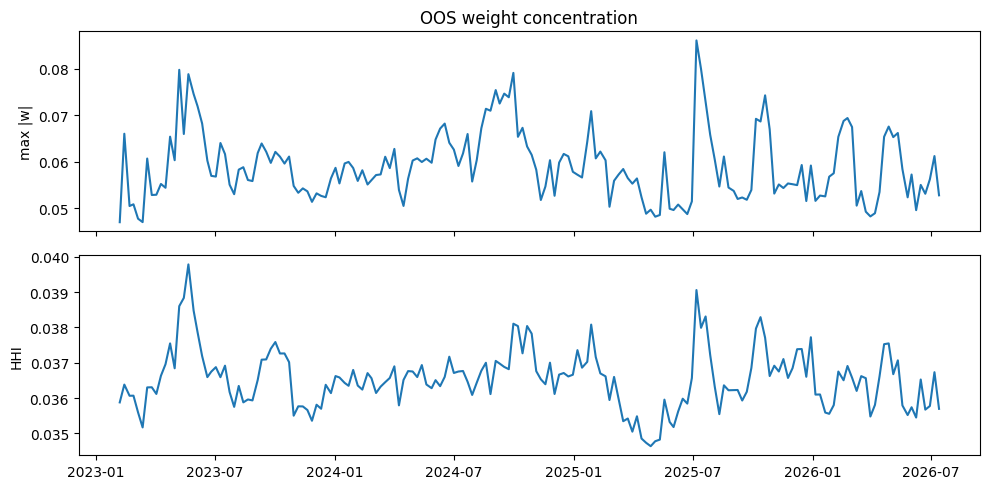

In [11]:
conc = concentration_vs_returns(
    result.entry_weights.reindex(oos_rets.index),
    oos_rets,
)
display(conc["summary"].to_frame("value"))
display(conc["corr"])
fig = plot_concentration(conc["stats"], title="OOS weight concentration")
plt.show()


### 4.6 Feature attrition

How many of the static universe names survive complete-case feature coverage,
and which features are binding.


,n_candidates,n_complete,n_dropped
count,4165.000000,4165.000000,4165.000000
mean,98.581993,40.627371,57.954622
std,1.592433,28.531803,29.760372
min,60.000000,0.000000,12.000000
25%,97.000000,0.000000,32.000000
50%,100.000000,50.000000,50.000000
75%,100.000000,65.000000,100.000000
max,100.000000,68.000000,100.000000


,total_blame,exclusive_blame
gross_profitability,0.398910,0.269002
gdelt_tone_x_attention_21,0.366403,0.039108
gdelt_attention_5,0.330904,0.000000
smart_residual_mom_189_42,0.293234,0.000000
smart_beta_hml_252,0.262790,0.000000
val_roc_pb_252,0.182682,0.013584
val_mom_dist_252_21,0.162718,0.000000
val_roc_pe_252,0.122345,0.001496
size_mom_126,0.111473,0.000000
beta_mkt_interact,0.061618,0.000000


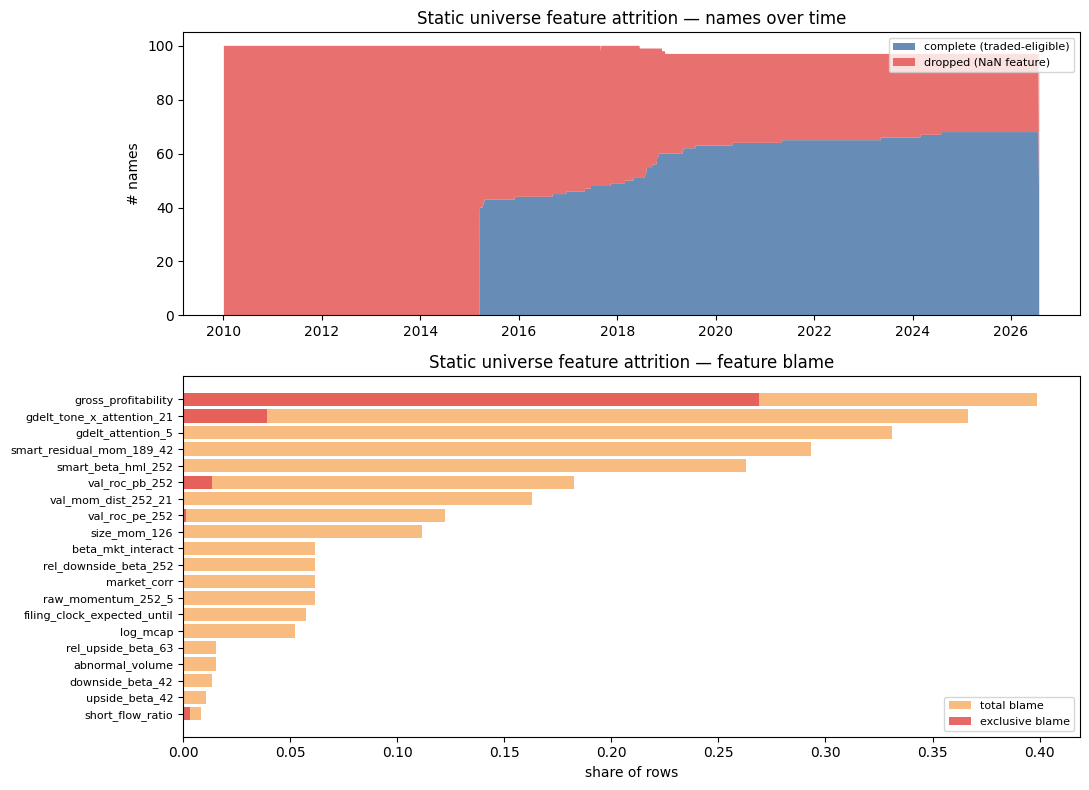

In [12]:
_feat = pd.read_parquet(PATHS["features"])
_feat["date"] = pd.to_datetime(_feat["date"])
_feat["ticker"] = _feat["ticker"].astype(str).str.strip().str.upper()
# Candidates = names present on each date in the engineered panel
# (static top-100 universe). Complete-case after ffill mirrors Ridge training.
attrition_summary = feature_attrition_summary(
    _feat,
    [c for c in FEATURE_COLS_ATTRITION if c in _feat.columns],
    candidate_mask=None,
    ffill=True,
)
display(attrition_summary["by_date"].describe())
display(
    pd.concat(
        [attrition_summary["total_blame"], attrition_summary["exclusive_blame"]],
        axis=1,
    ).head(20)
)
fig = plot_feature_attrition(
    attrition_summary, title="Static universe feature attrition"
)
plt.show()


## 5. Save tearsheet PDF

Exports metrics, performance overview, and underperformance diagnostics.


In [13]:
pdf_path = os.path.join(
    ART, f"tearsheet_n{N_STAR}_{TIMING_STAR}_{WEIGHT_STAR}.pdf"
)
LABEL_STAR = (
    LABEL_COL_MON_FRI
    if TIMING_STAR == TIMING_MON_OPEN_FRI_CLOSE
    else LABEL_COL
)
write_tearsheet_pdf(
    pdf_path,
    result=result,
    is_dates=is_dates,
    metrics=metrics,
    title=f"S1 L/S N={N_STAR} {TIMING_STAR} {WEIGHT_STAR}",
    preds=preds,
    features_path=PATHS["features"],
    label_col=LABEL_STAR,
    attrition=attrition_summary,
)
print(f"saved {pdf_path}")


saved c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s1_equities\artifacts\tearsheet_n15_mon_open_mon_open_inv_vol.pdf
